## Numpy基础
- 2005年从Scipy脱离出来，和Numerical整合。
    - 是基于c语言实现的，很多内置函数都是优化过的，所以速度快。可以直接数组上执行元素级别操作，以及超好用的广播功能。
    - 向量化操作，simd，现在cpu都有这个功能，就是单个指令多个数据。也就是将一次处理一个数字，改为一次处理一堆数字，不需要我们写循环。
- Numpy的2个核心作用：定义操作函数以及存储多维数组。
    - 占用的空间更小,注意得是大数据的时候。在处理大量数值数据的时候，首选！
    - 很多优化的数学库，比如mean、sum等很方便。
    - 布尔数组索引，意思是用布尔值组成的数组作为索引值，但是长度要保持一致，这时候，true返回的元素被保留，false的舍去。

` Python列表是非连续存储,Numpy是连续存储的，因此对类型要求就高了一些。 ` 

` Python列表速度要比Numpy慢` 

In [1]:
a = [1,2,3]
a.append([5])
print(id(a[0]),id(a[1]),id(a[2]),id(a[3]))


4340670224 4340670256 4340670288 4393402688


In [2]:
import numpy as np
b = np.array([1,2,3])
b = np.append(b,[5]) 
print(id(b[0]),id(b[1]),id(b[2]),id(b[3]))

4392338704 4392338704 4392338704 4392338704


In [3]:
c = np.arange(5)
print(c)

[0 1 2 3 4]


In [4]:
l = list(range(10000))
%timeit [i*i for i in l]
a = np.arange(10000)
%timeit a*a

172 μs ± 1.03 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
3.5 μs ± 7.1 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


##### 附：下面也是一常用的测速方式，不使用notebook魔法工具

In [ ]:
import timeit
stmt = '''
sum = 0
for i in alist:
    sum = sum + 1'''
timeit.timeit(stmt=stmt,setup='alist = list(range(1,100000))',number=1000)

1.6418464589805808

In [7]:
timeit.timeit(stmt='np.sum(alist)',setup='import numpy as np;alist = np.arange(100000)',number=1000)

0.02793075001682155

### Numpy数组操作和布尔索引

In [8]:
#创建数组
import numpy as np

# 创建全零数组
zeros = np.zeros((3, 4))  # 3行4列的全零数组
print(zeros)

# 创建全一数组
ones = np.ones((2, 3))  # 2行3列的全一数组
print(ones)

# 创建等差数列数组
range_arr = np.arange(0, 10, 2)  # 从0到10（不包括），步长2
print(range_arr)  # 输出: [0 2 4 6 8]

# 创建等间隔数组（指定元素个数）
linspace_arr = np.linspace(0, 1, 5)  # 从0到1，生成5个数
print(linspace_arr)  # 输出: [0.   0.25 0.5  0.75 1.  ]

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1. 1. 1.]
 [1. 1. 1.]]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]


In [11]:
#数组属性
arr = np.array([[1, 2], [3, 4]])

# 查看数组形状
print(arr.shape)  # 输出: (2, 2)

# 查看数组维数
print(arr.ndim)  # 输出: 2

# 查看数组元素总数
print(arr.size)  # 输出: 4

# 查看数组数据类型
print(arr.dtype)  # 输出: int64

(2, 2)
2
4
int64


In [14]:
# 数组维度和形状
arr = np.array([1])
print(arr.shape)  
print(arr.ndim)  

(1,)
1


In [16]:
#数组操作

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# 元素相加
print(a + b)  

# 元素相乘
print(a * b)  # np.multiply(a, b)

# 数组点积
print(np.dot(a, b))  # np.matmul(a, b)

# 广播操作（标量运算）
print(a * 2)  

[5 7 9]
[ 4 10 18]
32
[2 4 6]


In [15]:
#np.multiply() 逐元素相乘

import numpy as np

a = np.array([[1, 2], 
              [3, 4]])
b = np.array([[5, 6], 
              [7, 8]])

# 元素乘法
result = np.multiply(a, b)
print(result)

[[ 5 12]
 [21 32]]


In [ ]:
# np.dot() 一维数组返回点积
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(np.dot(a, b))

32


In [19]:
# np.dot() 二维数组返回矩阵乘法
a = np.array([[1, 2, 3]])
print(a.shape)
b = np.array([[1], [2], [3]])
print(b.shape)
c = np.dot(a, b)
#c = a @ b
#c = np.matmul(a, b)
print(c)

(1, 3)
(3, 1)
[[14]]


In [21]:
#索引和切片
arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# 取第1行
print(arr[1]) 

# 取第0行第2列
print(arr[0, 2])  

# 切片：取前两行
print(arr[:2]) 


[4 5 6]
3
[[1 2 3]
 [4 5 6]]


In [22]:
# 条件筛选
import numpy as np
a = np.array(range(1000))

## numpy bool index
a = np.arange(10)
a[a < 5] * 2


array([0, 2, 4, 6, 8])

[[ 0  1]
 [ 2  3]
 [ 4  5]
 [ 6  7]
 [ 8  9]
 [10 11]
 [12 13]
 [14 15]
 [16 17]
 [18 19]
 [20 21]
 [22 23]
 [24 25]
 [26 27]
 [28 29]]


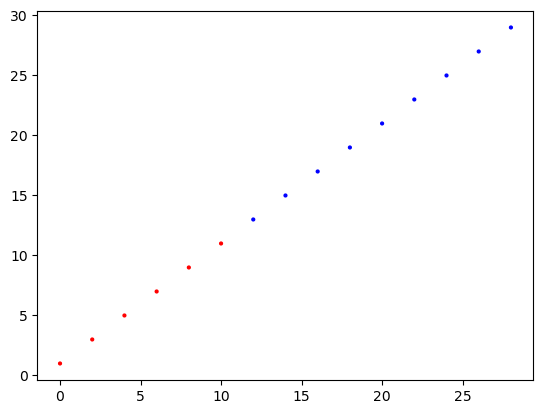

In [23]:
import matplotlib.pyplot as plt 
import numpy as np
data = np.arange(30).reshape(15,-1)
print(data)
x = data[:,0]
y = data[:,1]
plt.scatter(x,y,4,c=np.where(x>10,'b','r'))


#### Numpy广播规则
- 如果两个数组的 ndim（维度数）不同，NumPy 会自动在维度较小的数组的形状（shape）前面补 1，直到两个数组的维度相同。
- 如果两个数组在某个维度上的大小相同，或者其中一个数组在该维度上的大小为 1，那么这两个数组在该维度上是兼容的。
- 广播之后，数组的形状将是每个维度上的最大值。
- 如果两个数组在某个维度上的大小不一致，且都不为1，则会抛出 ValueError 异常。

In [44]:
# 标量与数组的广播
import numpy as np

a = np.array([1, 2, 3])
b = 2

# 标量 b 被广播到与 a 相同的形状 [2, 2, 2]
result = a * b
print(result)  # 输出: [2 4 6]

[2 4 6]


In [24]:
# 一维数组与二维数组的广播
a = np.array([[1, 2, 3],
              [4, 5, 6]])
print(a.shape)
b = np.array([10, 20, 30])
print(b.shape)

# b 被广播为与 a 相同的形状 (2, 3)
result = a + b
print(result)

(2, 3)
(3,)
[[11 22 33]
 [14 25 36]]


In [46]:
# 列向量与行向量的广播
a = np.array([[1],
              [2],
              [3]])  # 形状 (3, 1)
b = np.array([10, 20, 30])  # 形状 (3,)

result = a + b
print(result)

[[11 21 31]
 [12 22 32]
 [13 23 33]]


In [47]:
# 不同维度的数组广播
a = np.array([1, 2])  # 形状 (2,)
b = np.array([[10], 
              [20], 
              [30]])  # 形状 (3, 1)

result = a * b
print(result)


[[10 20]
 [20 40]
 [30 60]]


In [ ]:
# 什么情况下无法广播？
# 形状在某个维度上既不相等、也不是 1; 或维度数不同且“对齐后”某一维不兼容
a = np.array([[1, 2],
              [3, 4],
              [5, 6]])  # 形状 (3,2)
b = np.array([[10,10], 
              [20,20]])  # 形状 (2,2)

print(a + b)


ValueError: operands could not be broadcast together with shapes (3,2) (2,2) 